In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
ml_dataframe = pd.read_csv("ml_dataframe_clipped_with_medain_view_cart_view_focus_ratio.csv")
ml_dataframe.head()

,total_views,total_carts,unique_products,median_view_price,median_cart_price,target_purchase,session_duration_seconds,views_per_minute,focus_ratio,first_cart_time_seconds
0,1,0,1,69.17,0.0,0,0.0,60.000000,1.0,0.0
1,9,0,5,716.76,0.0,0,485.0,1.111111,1.8,0.0
2,1,0,1,10.18,0.0,0,0.0,60.000000,1.0,0.0
3,6,0,3,362.76,0.0,0,133.0,2.686567,2.0,0.0
4,2,0,1,127.15,0.0,0,56.0,2.105263,2.0,0.0


In [31]:
ml_dataframe.shape

(1378222, 10)

In [32]:
ml_dataframe['session_duration_seconds'].describe()

count    1.378222e+06
mean     2.969126e+02
std      6.244187e+02
min      0.000000e+00
25%      0.000000e+00
50%      5.900000e+01
75%      2.840000e+02
max      3.600000e+03
Name: session_duration_seconds, dtype: float64

In [19]:
ml_dataframe.sample(4)

,total_views,total_carts,unique_products,avg_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
411117,10,0,9,58.445,0.00,0,153.0,3.896104,0.0
891244,1,0,1,130.220,0.00,0,0.0,60.000000,0.0
487542,2,0,2,497.940,0.00,0,29.0,4.000000,0.0
362510,1,2,1,202.320,202.32,1,90.0,0.659341,39.0


In [33]:
# 'Unnamed' wale kisi bhi column ko safely drop karna
ml_dataframe = ml_dataframe.loc[:, ~ml_dataframe.columns.str.contains('^Unnamed')]

# Verify karna ki column hat gaya hai
display(ml_dataframe.sample(4))

,total_views,total_carts,unique_products,avg_view_price,median_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
1089476,1,0,1,250.460,250.460,0.0,0,0.0,60.000000,0.0
1372164,2,0,2,6.115,6.115,0.0,0,10.0,10.909091,0.0
170343,1,0,1,167.060,167.060,0.0,0,0.0,60.000000,0.0
207615,1,0,1,61.750,61.750,0.0,0,0.0,60.000000,0.0


In [36]:
ml_dataframe

,total_views,total_carts,unique_products,avg_view_price,median_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
0,1,0,1,69.170000,69.170,0.00,0,0.0,60.000000,0.0
1,9,0,5,822.974444,716.760,0.00,0,485.0,1.111111,0.0
2,1,0,1,10.180000,10.180,0.00,0,0.0,60.000000,0.0
3,6,0,3,362.676667,362.760,0.00,0,133.0,2.686567,0.0
4,2,0,1,127.150000,127.150,0.00,0,56.0,2.105263,0.0
...,...,...,...,...,...,...,...,...,...,...
1378217,12,1,9,809.506667,845.185,977.86,1,801.0,0.897756,721.0
1378218,4,1,4,59.842500,62.555,32.15,0,177.0,1.348315,177.0
1378219,1,0,1,244.540000,244.540,0.00,0,0.0,60.000000,0.0
1378220,1,0,1,82.630000,82.630,0.00,0,0.0,60.000000,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# STEP 1: Features (X) aur Target (y) ko alag karna
# 'user_session' aur 'target_purchase' ko features se hata rahe hain
X = ml_dataframe.drop(columns=['user_session', 'target_purchase'])
y = ml_dataframe['target_purchase']

# STEP 2: Train-Test Split (80% Training, 20% Testing)
# stratify=y lagana bohot zaroori hai imbalanced data ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")

# STEP 3: Calculate Dynamic Imbalance Weight
# Formula: Total Zeros (Negative) / Total Ones (Positive) in Training Data
imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Applying scale_pos_weight: {imbalance_weight:.2f}\n")

# STEP 4: Model Initialize aur Train Karna
# Hum XGBoost use kar rahe hain kyunki ye tabular data ka "King" hai
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_weight, # Galti ki Saza (Penalty)
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1 # Pura CPU use karne ke liye fast training
)

print("Training the XGBoost Model... (This might take a few seconds)")
xgb_model.fit(X_train, y_train)
print("Training Complete! ✅\n")

# STEP 5: Predictions Make Karna
y_pred = xgb_model.predict(X_test)

# STEP 6: ALL ACCURACY METRICS PRINT KARNA
print("-" * 50)
print("🎯 FINAL MODEL EVALUATION REPORT 🎯")
print("-" * 50)

# 1. Overall Accuracy (Ye imbalanced data me dhokha hoti hai, ispar zyada dhyan na de)
acc = accuracy_score(y_test, y_pred)
print(f"1. Overall Accuracy Score: {acc * 100:.2f}%\n")

# 2. Classification Report (Asli test yahan hai)
print("2. Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Plot Karna
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchased (0)', 'Purchased (1)'], 
            yticklabels=['Not Purchased (0)', 'Purchased (1)'])
plt.title('Confusion Matrix: Real vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Predicted by XGBoost', fontsize=12)
plt.ylabel('Actual Truth', fontsize=12)
plt.show()

Feature Selection and Model Training

In [24]:
ml_dataframe.head()

,total_views,total_carts,unique_products,avg_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
0,1,0,1,69.170000,0.0,0,0.0,60.000000,0.0
1,9,0,5,822.974444,0.0,0,485.0,1.111111,0.0
2,1,0,1,10.180000,0.0,0,0.0,60.000000,0.0
3,6,0,3,362.676667,0.0,0,133.0,2.686567,0.0
4,2,0,1,127.150000,0.0,0,56.0,2.105263,0.0


Best_Feautres_through_Exhaustive_Search

In [29]:
ml_dataframe

,total_views,total_carts,unique_products,avg_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
0,1,0,1,69.170000,0.00,0,0.0,60.000000,0.0
1,9,0,5,822.974444,0.00,0,485.0,1.111111,0.0
2,1,0,1,10.180000,0.00,0,0.0,60.000000,0.0
3,6,0,3,362.676667,0.00,0,133.0,2.686567,0.0
4,2,0,1,127.150000,0.00,0,56.0,2.105263,0.0
...,...,...,...,...,...,...,...,...,...
1378217,12,1,9,809.506667,977.86,1,801.0,0.897756,721.0
1378218,4,1,4,59.842500,32.15,0,177.0,1.348315,177.0
1378219,1,0,1,244.540000,0.00,0,0.0,60.000000,0.0
1378220,1,0,1,82.630000,0.00,0,0.0,60.000000,0.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, f1_score, recall_score
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

sns.set_theme(style="whitegrid")

# Puraane 'Unnamed' columns agar hain toh unhe safely hatana
X_full = ml_dataframe.loc[:, ~ml_dataframe.columns.str.contains('^Unnamed')].drop(columns=['target_purchase'])
y_full = ml_dataframe['target_purchase']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("=" * 70)
print("🔍 PHASE 1: EXHAUSTIVE FEATURE SELECTION (Optimizing for RECALL)")
print("=" * 70)

# Time bachane ke liye Training data ka 10% sample le rahe hain sirf EFS ke liye
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, train_size=0.4, random_state=42, stratify=y_train)

# Base model for selection
xgb_base = XGBClassifier(scale_pos_weight=imbalance_weight, random_state=42, n_jobs=-1)

# EFS Setup (Min 2 columns se lekar saare columns tak check karega)
efs = EFS(xgb_base, 
          min_features=2,
          max_features=X_train.shape[1],
          scoring='recall', # Specially prioritizing Recall
          print_progress=True,
          cv=2, # Fast evaluation
          n_jobs=-1)

print(f"Running EFS on {len(X_train_sample)} rows to find the best feature combination...")
efs = efs.fit(X_train_sample, y_train_sample)

best_features = list(efs.best_feature_names_)
print(f"\n🏆 BEST FEATURES FOR RECALL: {best_features}")
print(f"🔥 EFS Best Recall Score: {efs.best_score_:.4f}\n")

# Ab hum apne X_train aur X_test ko sirf inhi best columns tak limit kar denge
X_train_best = X_train[best_features]
X_test_best = X_test[best_features]


🔍 PHASE 1: EXHAUSTIVE FEATURE SELECTION (Optimizing for RECALL)
Running EFS on 441030 rows to find the best feature combination...


Features: 502/502


🏆 BEST FEATURES FOR RECALL: ['total_carts', 'unique_products', 'session_duration_seconds', 'focus_ratio']
🔥 EFS Best Recall Score: 0.8936



⚙️ PHASE 2: ADVANCED HYPERPARAMETER TUNING (Deep Grid)
Starting Cross-Validation Tuning (Trying 30 combinations, totalling 90 fits)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
✅ Tuning Completed in 9.01 minutes!

🏆 WINNING HYPERPARAMETERS: {'subsample': 1.0, 'scale_pos_weight': np.float64(25.19333258013493), 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.8}
📈 PHASE 3: COMPREHENSIVE EVALUATION (ROC-AUC & MATRIX)
1. OVERALL SCORES:
-> Accuracy Score: 88.56%
-> Recall Score (Class 1): 92.36%
-> F1 Score (Class 1): 47.56%

2. DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.88      0.94    260156
           1       0.32      0.92      0.48     15489

    accuracy                           0.89    275645
   macro avg       0.66      0.90      0.71    275645
weighted avg       0.96      0.89      0.91    275645



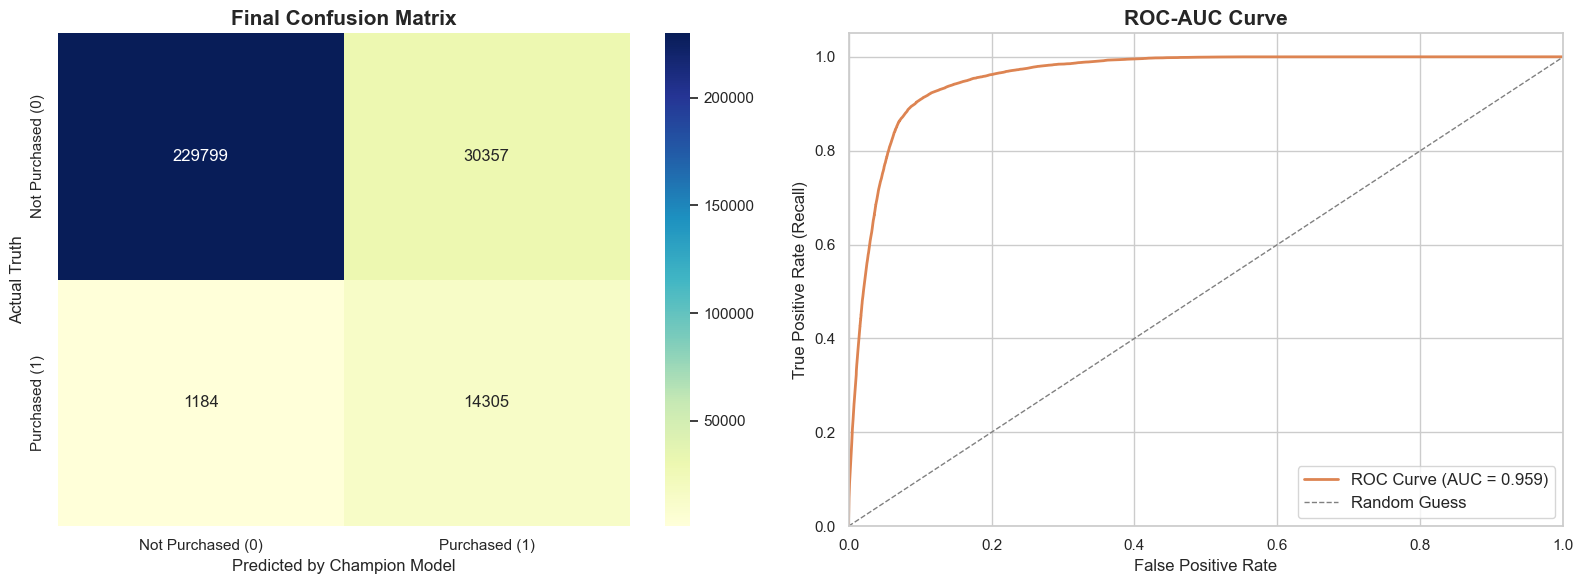

In [4]:

print("=" * 70)
print("⚙️ PHASE 2: ADVANCED HYPERPARAMETER TUNING (Deep Grid)")
print("=" * 70)

# 🚀 THE ULTIMATE HYPERPARAMETER GRID
param_grid = {
    'n_estimators': [100, 200, 300, 400],              # Kitne trees banayega (Zyada trees + kam learning rate = Best)
    'max_depth': [3, 5, 7, 9],                         # Tree kitna gehra hoga
    'learning_rate': [0.01, 0.05, 0.1, 0.2],           # Seekhne ki speed
    'subsample': [0.7, 0.8, 0.9, 1.0],                 # Overfitting rokne ke liye rows ka fraction
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],          # Overfitting rokne ke liye columns ka fraction
    'gamma': [0, 0.5, 1, 2],                           # Strictness for splitting
    'scale_pos_weight': [imbalance_weight, imbalance_weight * 1.2, imbalance_weight * 1.5] # Pushing hard for Recall
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearch Setup (Optimizing strictly for Recall)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,           # MAGIC NUMBER: Pehle 5 tha, ab hum 30 random combinations try karenge!
    scoring='recall',    
    cv=skf,
    verbose=2,           # Isey 2 kar diya hai taaki aapko screen par live progress dikhe
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
print(f"Starting Cross-Validation Tuning (Trying {random_search.n_iter} combinations, totalling {random_search.n_iter * 3} fits)...")
random_search.fit(X_train_best, y_train)
print(f"✅ Tuning Completed in {(time.time() - start_time)/60:.2f} minutes!\n")

champion_model = random_search.best_estimator_
print(f"🏆 WINNING HYPERPARAMETERS: {random_search.best_params_}")


print("=" * 70)
print("📈 PHASE 3: COMPREHENSIVE EVALUATION (ROC-AUC & MATRIX)")
print("=" * 70)

# Predictions nikalna
y_pred = champion_model.predict(X_test_best)
y_probs = champion_model.predict_proba(X_test_best)[:, 1]

# 1. SCORES PRINT KARNA
print("1. OVERALL SCORES:")
print(f"-> Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"-> Recall Score (Class 1): {recall_score(y_test, y_pred)*100:.2f}%")
print(f"-> F1 Score (Class 1): {f1_score(y_test, y_pred)*100:.2f}%\n")

# 2. CLASSIFICATION REPORT
print("2. DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# 3. GRAPHS (Confusion Matrix & ROC-AUC)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Not Purchased (0)', 'Purchased (1)'], 
            yticklabels=['Not Purchased (0)', 'Purchased (1)'], ax=ax1)
ax1.set_title('Final Confusion Matrix', fontsize=15, fontweight='bold')
ax1.set_xlabel('Predicted by Champion Model', fontsize=12)
ax1.set_ylabel('Actual Truth', fontsize=12)

# Graph B: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='#DD8452', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess') 
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax2.set_title('ROC-AUC Curve', fontsize=15, fontweight='bold')
ax2.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
ml_dataframe.to_csv('')

,total_views,total_carts,unique_products,avg_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
0,1,0,1,69.170000,0.00,0,0.0,60.000000,0.0
1,9,0,5,822.974444,0.00,0,485.0,1.111111,0.0
2,1,0,1,10.180000,0.00,0,0.0,60.000000,0.0
3,6,0,3,362.676667,0.00,0,133.0,2.686567,0.0
4,2,0,1,127.150000,0.00,0,56.0,2.105263,0.0
...,...,...,...,...,...,...,...,...,...
1378217,12,1,9,809.506667,977.86,1,801.0,0.897756,721.0
1378218,4,1,4,59.842500,32.15,0,177.0,1.348315,177.0
1378219,1,0,1,244.540000,0.00,0,0.0,60.000000,0.0
1378220,1,0,1,82.630000,0.00,0,0.0,60.000000,0.0
